In [74]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_errorr

In [75]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [76]:
device

device(type='cpu')

In [77]:
ticker = 'AAPL'
df = yf.download(ticker, '2020-01-01')

[*********************100%***********************]  1 of 1 completed


In [78]:
df


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400
2020-01-03,71.630623,72.389242,71.406651,71.563190,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000
2020-01-08,73.017845,73.318885,71.565629,71.565629,132079200
...,...,...,...,...,...
2026-07-14,314.859985,316.190002,311.910004,313.760010,36336800
2026-07-15,327.500000,328.730011,317.320007,317.619995,60957600


<Axes: xlabel='Date'>

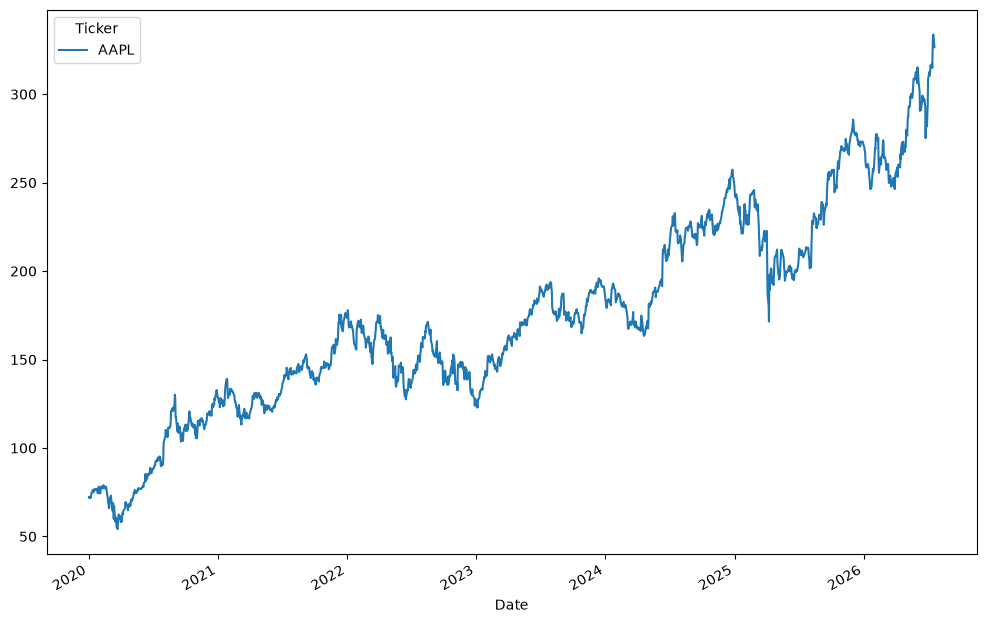

In [79]:
df.Close.plot(figsize=(12,8))

In [80]:
scaler = StandardScaler()

df['Close'] = scaler.fit_transform(df['Close'])


In [81]:
df.Close

Ticker,AAPL
Date,
2020-01-02,-1.779193
2020-01-03,-1.791506
2020-01-06,-1.781512
2020-01-07,-1.787457
2020-01-08,-1.767217
...,...
2026-07-14,2.467096
2026-07-15,2.688405
2026-07-16,2.789254


In [82]:
seq_length = 30
data = []

for i in range(len(df) - seq_length):
    data.append(df.Close[i:i+seq_length])

data = np.array(data)



In [83]:
data

array([[[-1.77919251],
        [-1.79150564],
        [-1.78151186],
        ...,
        [-1.69478218],
        [-1.6627019 ],
        [-1.67255034]],

       [[-1.79150564],
        [-1.78151186],
        [-1.78745736],
        ...,
        [-1.6627019 ],
        [-1.67255034],
        [-1.67221145]],

       [[-1.78151186],
        [-1.78745736],
        [-1.76721734],
        ...,
        [-1.67255034],
        [-1.67221145],
        [-1.6973604 ]],

       ...,

       [[ 2.47304916],
        [ 2.38655672],
        [ 2.40354007],
        ...,
        [ 2.50999202],
        [ 2.46709578],
        [ 2.68840452]],

       [[ 2.38655672],
        [ 2.40354007],
        [ 2.33543143],
        ...,
        [ 2.46709578],
        [ 2.68840452],
        [ 2.78925412]],

       [[ 2.40354007],
        [ 2.33543143],
        [ 2.23388186],
        ...,
        [ 2.68840452],
        [ 2.78925412],
        [ 2.7976579 ]]], shape=(1614, 30, 1))

In [84]:
train_size = int(0.8 * len(data))
X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
X_test= torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [85]:
class PredictionModule(nn.Module):

    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super().__init__()

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(
            self.num_layers,
            x.size(0),
            self.hidden_dim,
            device=device
        )

        c0 = torch.zeros(
            self.num_layers,
            x.size(0),
            self.hidden_dim,
            device=device
        )

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))

        out = self.fc(out[:, -1, :])

        return out

In [86]:
model = PredictionModule (input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

In [87]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [88]:
num_epochs = 200

for i in range(num_epochs):
    y_train_pred = model(X_train)

    loss = criterion(y_train_pred, y_train)

    if i % 25 == 0:
        print(i, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

0 0.5756329298019409
25 0.01434152852743864
50 0.00521727092564106
75 0.004479524213820696
100 0.004056666046380997
125 0.003762691281735897
150 0.0035452069714665413
175 0.0033753111492842436


In [89]:
model.eval()

y_test_pred = model(X_test)

y_train_pred = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())



In [92]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])

In [93]:
train_rmse

3.2465193271636963

In [94]:
test_rmse

10.722363471984863

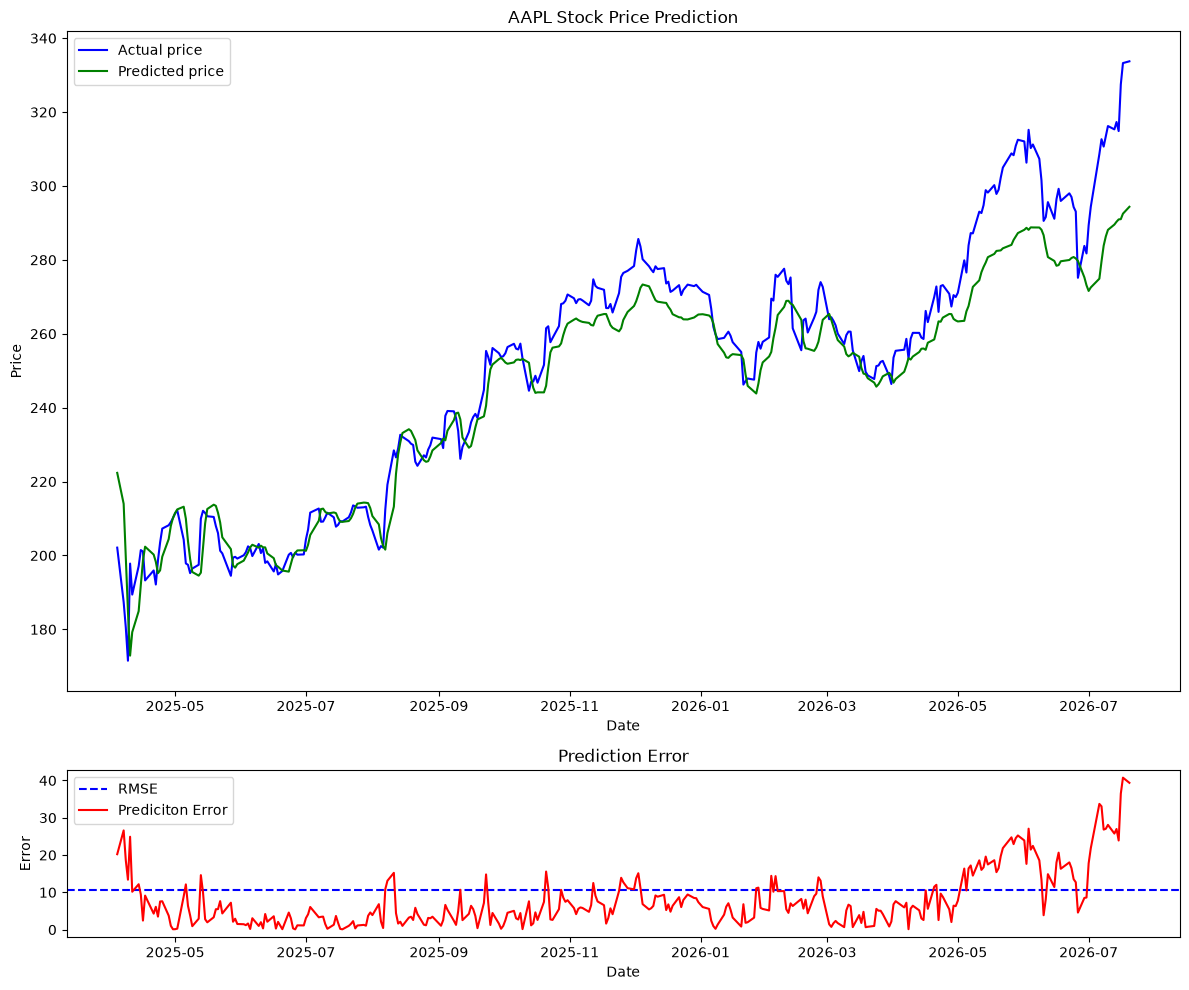

In [99]:
fig = plt.figure(figsize=(12,10))

gs = fig.add_gridspec(4,1)

ax1 = fig.add_subplot(gs[:3,0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color='blue', label = 'Actual price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color='green', label = 'Predicted price')
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel('Date')
plt.ylabel('Price')

ax2 = fig.add_subplot(gs[3, 0])
ax2.axhline(test_rmse, color = 'blue', linestyle = '--', label='RMSE')
ax2.plot(df[-len(y_test):].index, abs(y_test-y_test_pred), 'r', label='Prediciton Error')
ax2.legend()
plt.title('Prediction Error')
plt.xlabel('Date')
plt.ylabel('Error')
plt.tight_layout()
plt.show()